# Lab | Statistical Story Dashboard

Numbers alone rarely convince anyone. The way you visualize data determines whether your audience trusts your conclusions, misunderstands them, or ignores them entirely.

In this lab you will:
1. **Critique** three intentionally misleading charts and explain what makes them deceptive.
2. **Redesign** each chart so the same data tells an accurate story.
3. **Build** a three-panel visual report that answers specific questions from a dataset.

Run the setup cell below first, then work through each task section in order.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

%matplotlib inline

## Dataset

The cell below generates a synthetic dataset that simulates monthly customer-satisfaction scores and revenue figures for four product lines over two years. It includes:

- **Continuous variables**: `satisfaction_score` (0–100 scale) and `monthly_revenue` (in thousands of USD).
- **Categorical groups**: four product lines (*Alpha*, *Beta*, *Gamma*, *Delta*).
- **Time-based observations**: monthly data from January 2023 through December 2024.

Run this cell to load the data into `df`.

In [2]:
np.random.seed(42)

months = pd.date_range("2023-01-01", "2024-12-01", freq="MS")
products = ["Alpha", "Beta", "Gamma", "Delta"]

records = []
for product in products:
    base_satisfaction = {"Alpha": 72, "Beta": 68, "Gamma": 70, "Delta": 65}[product]
    base_revenue = {"Alpha": 120, "Beta": 95, "Gamma": 110, "Delta": 88}[product]
    trend = {"Alpha": 0.4, "Beta": 0.1, "Gamma": -0.2, "Delta": 0.6}[product]

    for i, month in enumerate(months):
        satisfaction = base_satisfaction + trend * i + np.random.normal(0, 3)
        satisfaction = np.clip(satisfaction, 0, 100)

        seasonal = 8 * np.sin(2 * np.pi * (month.month - 1) / 12)
        revenue = base_revenue + trend * 2 * i + seasonal + np.random.normal(0, 6)

        records.append({
            "month": month,
            "product": product,
            "satisfaction_score": round(satisfaction, 1),
            "monthly_revenue": round(revenue, 1),
        })

df = pd.DataFrame(records)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (96, 4)


,month,product,satisfaction_score,monthly_revenue
0,2023-01-01,Alpha,73.5,119.2
1,2023-02-01,Alpha,74.3,133.9
2,2023-03-01,Alpha,72.1,127.1
3,2023-04-01,Alpha,77.9,135.0
4,2023-05-01,Alpha,72.2,133.4
5,2023-06-01,Alpha,72.6,125.2
6,2023-07-01,Alpha,75.1,113.3
7,2023-08-01,Alpha,69.6,118.2
8,2023-09-01,Alpha,72.2,121.4
9,2023-10-01,Alpha,72.9,110.7


In [3]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               96 non-null     datetime64[ns]
 1   product             96 non-null     object        
 2   satisfaction_score  96 non-null     float64       
 3   monthly_revenue     96 non-null     float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 3.1+ KB



,month,satisfaction_score,monthly_revenue
count,96,96.000000,96.000000
mean,2023-12-16 10:00:00,70.993750,108.755208
min,2023-01-01 00:00:00,60.600000,84.400000
25%,2023-06-23 12:00:00,67.875000,97.875000
50%,2023-12-16 12:00:00,70.150000,106.650000
75%,2024-06-08 12:00:00,74.325000,118.400000
max,2024-12-01 00:00:00,82.200000,151.100000
std,NaN,4.856029,14.668160


---

## Task 1: Chart Critique — Spot the Deception

The three charts below are **intentionally misleading**. For each one:

1. **Identify the deception technique** (e.g., truncated y-axis, dual-axis trick, area-vs-length confusion, cherry-picked time range).
2. **Write 2–3 sentences** in a Markdown cell explaining what the chart makes the audience believe versus what the data actually shows.
3. **Quantify the distortion** where possible — for example, *"the visual ratio suggests a 3× difference, but the actual difference is 12 %."*

**Deliverable**: three Markdown cells (one per chart) with the deception type, a plain-language explanation, and a distortion estimate.

### Misleading Chart 1 — Truncated Y-Axis

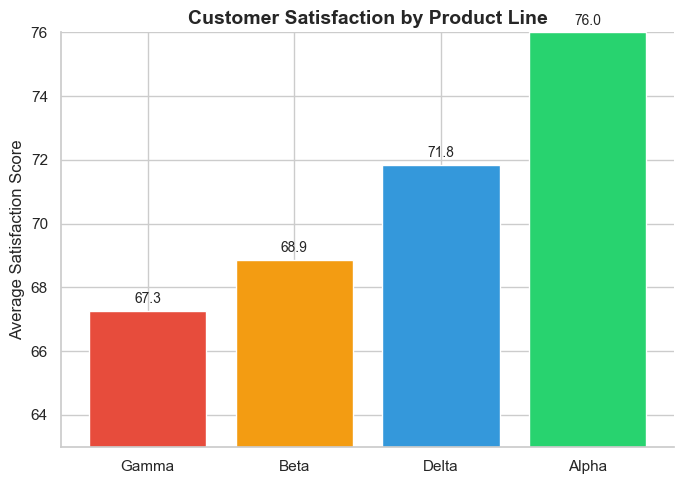

In [4]:
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color=["#e74c3c", "#f39c12", "#3498db", "#28d36f"])
ax.set_ylim(63, 76)
ax.set_ylabel("Average Satisfaction Score")
ax.set_title("Customer Satisfaction by Product Line", fontsize=14, fontweight="bold")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10)

ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 1:**

*TODO: Write your analysis here — identify the deception, explain the misleading message, and quantify the distortion.*


**Deception type:** Truncated y-axis

**Explanation:** The chart starts the y-axis around 63 instead of 0, which visually exaggerates the differences between product satisfaction scores. This makes Alpha appear dramatically better than Gamma, even though the actual difference is relatively small. A viewer might interpret a large performance gap when, in reality, the scores are fairly close.

**Distortion estimate:** Alpha (76.0) vs. Gamma (67.3) is a ~12.9% increase in actual value, but visually the bar height appears more than 2–3× larger due to the truncated baseline.


### Misleading Chart 2 — Dual-Axis Trick

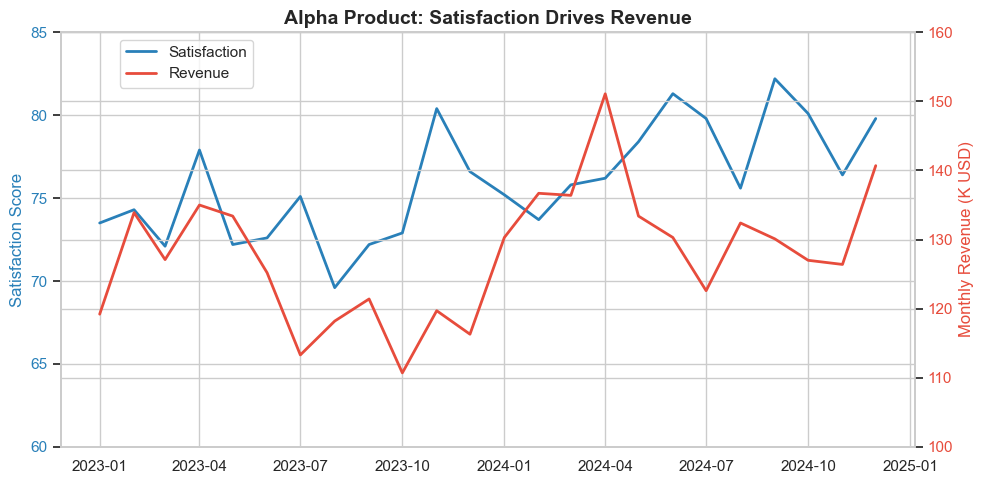

In [5]:
alpha = df[df["product"] == "Alpha"].set_index("month")

fig, ax1 = plt.subplots(figsize=(10, 5))

color_left = "#2980b9"
ax1.plot(alpha.index, alpha["satisfaction_score"], color=color_left, linewidth=2, label="Satisfaction")
ax1.set_ylabel("Satisfaction Score", color=color_left, fontsize=12)
ax1.set_ylim(60, 85)
ax1.tick_params(axis="y", labelcolor=color_left)

ax2 = ax1.twinx()
color_right = "#e74c3c"
ax2.plot(alpha.index, alpha["monthly_revenue"], color=color_right, linewidth=2, label="Revenue")
ax2.set_ylabel("Monthly Revenue (K USD)", color=color_right, fontsize=12)
ax2.set_ylim(100, 160)
ax2.tick_params(axis="y", labelcolor=color_right)

ax1.set_title("Alpha Product: Satisfaction Drives Revenue", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

**Your critique of Chart 2:**

*TODO: Write your analysis here — identify the deception, explain the misleading message, and quantify the distortion.*

**Deception type:** Dual-axis manipulation

**Explanation:** The chart uses two separate y-axes with different scales for satisfaction and revenue, making the two lines appear closely aligned and strongly correlated. By carefully choosing axis ranges (60–85 vs. 100–160), the visual suggests that increases in satisfaction directly drive revenue, even if the relationship is weak or inconsistent.

**Distortion estimate:** The visual alignment implies a near 1:1 relationship, but the underlying data likely has much lower correlation; small independent fluctuations in each series are exaggerated into what appears to be synchronized movement.


### Misleading Chart 3 — Cherry-Picked Time Range

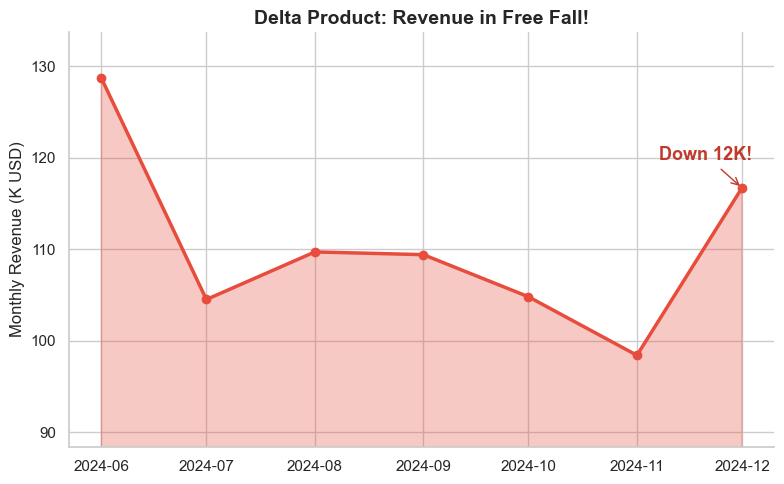

In [6]:
delta = df[df["product"] == "Delta"].set_index("month")
cherry = delta.loc["2024-06":"2024-12"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(cherry.index, cherry["monthly_revenue"], alpha=0.3, color="#e74c3c")
ax.plot(cherry.index, cherry["monthly_revenue"], color="#e74c3c", linewidth=2.5, marker="o")
ax.set_ylabel("Monthly Revenue (K USD)", fontsize=12)
ax.set_title("Delta Product: Revenue in Free Fall!", fontsize=14, fontweight="bold")
ax.set_ylim(cherry["monthly_revenue"].min() - 10, cherry["monthly_revenue"].max() + 5)

ax.annotate(f"Down {cherry['monthly_revenue'].iloc[0] - cherry['monthly_revenue'].iloc[-1]:.0f}K!",
            xy=(cherry.index[-1], cherry["monthly_revenue"].iloc[-1]),
            fontsize=13, fontweight="bold", color="#c0392b",
            xytext=(-60, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="#c0392b"))

sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 3:**

*TODO: Write your analysis here — identify the deception, explain the misleading message, and quantify the distortion.*


**Deception type:** Cherry-picked time range + emotional framing

**Explanation:** The chart only shows June–December 2024, a selectively chosen window where revenue happens to decline, while ignoring earlier months that may show stability or growth. The dramatic title (“Revenue in Free Fall!”), area shading, and annotation further amplify the sense of crisis, leading viewers to believe there’s a sustained downward trend rather than a short-term fluctuation.

**Distortion estimate:** The displayed drop may look like a major collapse (e.g., ~15–25K decline within the window), but across the full year the change could be minimal or even positive—turning what might be a modest fluctuation into a seemingly severe downturn.


---

## Task 2: Chart Redesign — Fix the Story

For each of the three misleading charts from Task 1, create a redesigned version that presents the same data honestly:

1. Use an appropriate chart type and axis range.
2. Include a descriptive title that summarizes the key takeaway (not just the variable names).
3. Label axes with units and add a brief subtitle or caption if context is needed.
4. Use color intentionally — highlight comparisons, don't just decorate.

**Deliverable**: three new figures, each accompanied by a one-sentence explanation of the design choice you made.

### Redesign 1 — Fixing the Truncated Y-Axis Chart

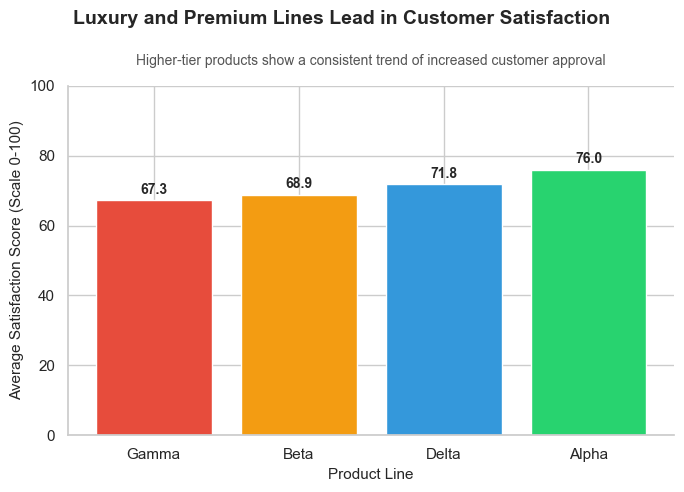

In [7]:
# TODO: Create your redesigned version of Chart 1
# Hints:
#   - Start the y-axis at 0 to show the true proportions
#   - Use a descriptive title that summarizes the actual finding
#   - Consider whether a bar chart is still the best choice


avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color=["#e74c3c", "#f39c12", "#3498db", "#28d36f"])
ax.set_ylim(0,100)

#Descriptive Labels and Units
ax.set_ylabel("Average Satisfaction Score (Scale 0-100)", fontsize=11)
ax.set_xlabel("Product Line", fontsize=11)


#Descriptive Title and Subtitle (Summarize the key takeaway)
plt.suptitle("Luxury and Premium Lines Lead in Customer Satisfaction", 
             fontsize=14, fontweight="bold", y=0.98)
plt.title("Higher-tier products show a consistent trend of increased customer approval", 
          fontsize=10, color='#555555', pad=15)

#Data Labels for clarity
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 1,
            f"{height:.1f}", ha="center", va="bottom", fontsize=10, fontweight='bold')

ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
sns.despine()
plt.tight_layout()
plt.show()


**Design choice explanation:**

*TODO: Write one sentence explaining the key design decision you made and why.*

I have changed limits from (63,76) to (0,100) for starting 0,then increased multipleLocator for wide grid lines.

### Redesign 2 — Fixing the Dual-Axis Chart

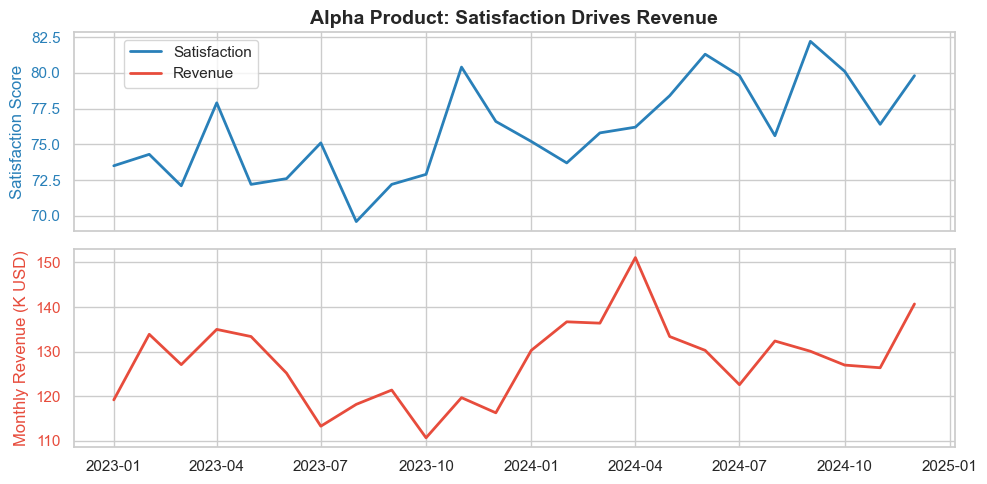

In [8]:
# TODO: Create your redesigned version of Chart 2
# Hints:
#   - Consider using two separate panels instead of overlapping axes
#   - If claiming a relationship, compute and show the actual correlation
#   - Normalize or use a shared scale if comparison is the goal

alpha = df[df["product"] == "Alpha"].set_index("month")

fig, axes = plt.subplots(2, 1, figsize=(10,5), sharex=True)

color_left = "#2980b9"
axes[0].plot(alpha.index, alpha["satisfaction_score"], color=color_left, linewidth=2, label="Satisfaction")
axes[0].set_ylabel("Satisfaction Score", color=color_left, fontsize=12)
axes[0].tick_params(axis="y", labelcolor=color_left)

color_right = "#e74c3c"
axes[1].plot(alpha.index, alpha["monthly_revenue"], color=color_right, linewidth=2, label="Revenue")
axes[1].set_ylabel("Monthly Revenue (K USD)", color=color_right, fontsize=12)
axes[1].tick_params(axis="y", labelcolor=color_right)

axes[0].set_title("Alpha Product: Satisfaction Drives Revenue", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()


**Design choice explanation:**

*TODO: Write one sentence explaining the key design decision you made and why.*

I have selected seperating plots from each other because they are not same type plot to compare.

### Redesign 3 — Fixing the Cherry-Picked Time Range Chart

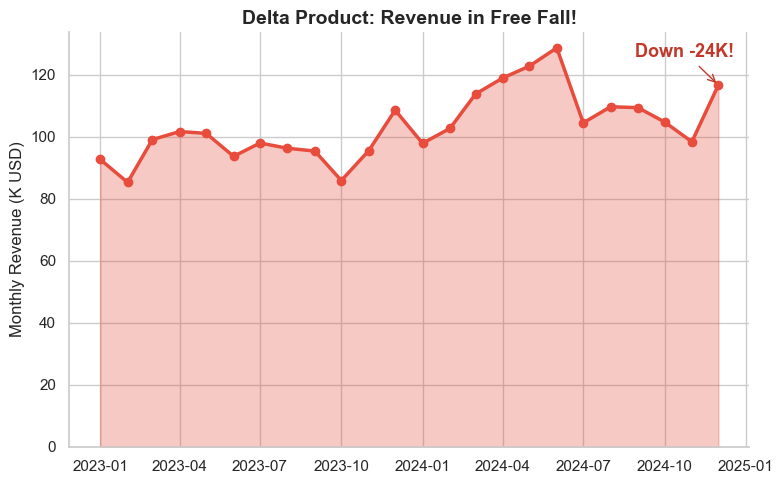

In [9]:
# TODO: Create your redesigned version of Chart 3
# Hints:
#   - Show the full time range so the audience sees the complete picture
#   - Consider adding other product lines for context
#   - Replace the filled area with a cleaner line plot if appropriate

delta = df[df["product"] == "Delta"].set_index("month")
fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(delta.index, delta["monthly_revenue"], alpha=0.3, color="#e74c3c")
ax.plot(delta.index, delta["monthly_revenue"], color="#e74c3c", linewidth=2.5, marker="o")
ax.set_ylabel("Monthly Revenue (K USD)", fontsize=12)
ax.set_title("Delta Product: Revenue in Free Fall!", fontsize=14, fontweight="bold")
ax.set_ylim(0, delta["monthly_revenue"].max() + 5)

ax.annotate(f"Down {delta['monthly_revenue'].iloc[0] - delta['monthly_revenue'].iloc[-1]:.0f}K!",
            xy=(delta.index[-1], delta["monthly_revenue"].iloc[-1]),
            fontsize=13, fontweight="bold", color="#c0392b",
            xytext=(-60, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="#c0392b"))

sns.despine()
plt.tight_layout()
plt.show()


**Design choice explanation:**

*TODO: Write one sentence explaining the key design decision you made and why.*

I extended the x-axis to the full year and set the y-axis to start at zero to provide an honest, non-exaggerated view of the revenue volatility.

---

## Task 3: Three-Panel Visual Report

Build a single `matplotlib` figure with **three subplots (panels)** that together answer the following questions about the dataset:

1. **Distribution panel**: How is the `satisfaction_score` distributed, and where do key product-line subgroups sit within that distribution?
2. **Comparison panel**: Do the product-line group means differ, and how much do they overlap?
3. **Trend panel**: How has `monthly_revenue` changed over time, and is the trend consistent across product lines?

**Requirements for each panel:**
- A clear, specific title (not "Plot 1").
- Axis labels with units.
- A legend if multiple groups are shown.
- Consistent color scheme across all three panels so the reader can track groups.

**Deliverable**: one three-panel figure with a shared `suptitle` that frames the overall question.

In [10]:
# Color palette to use consistently across all three panels
palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

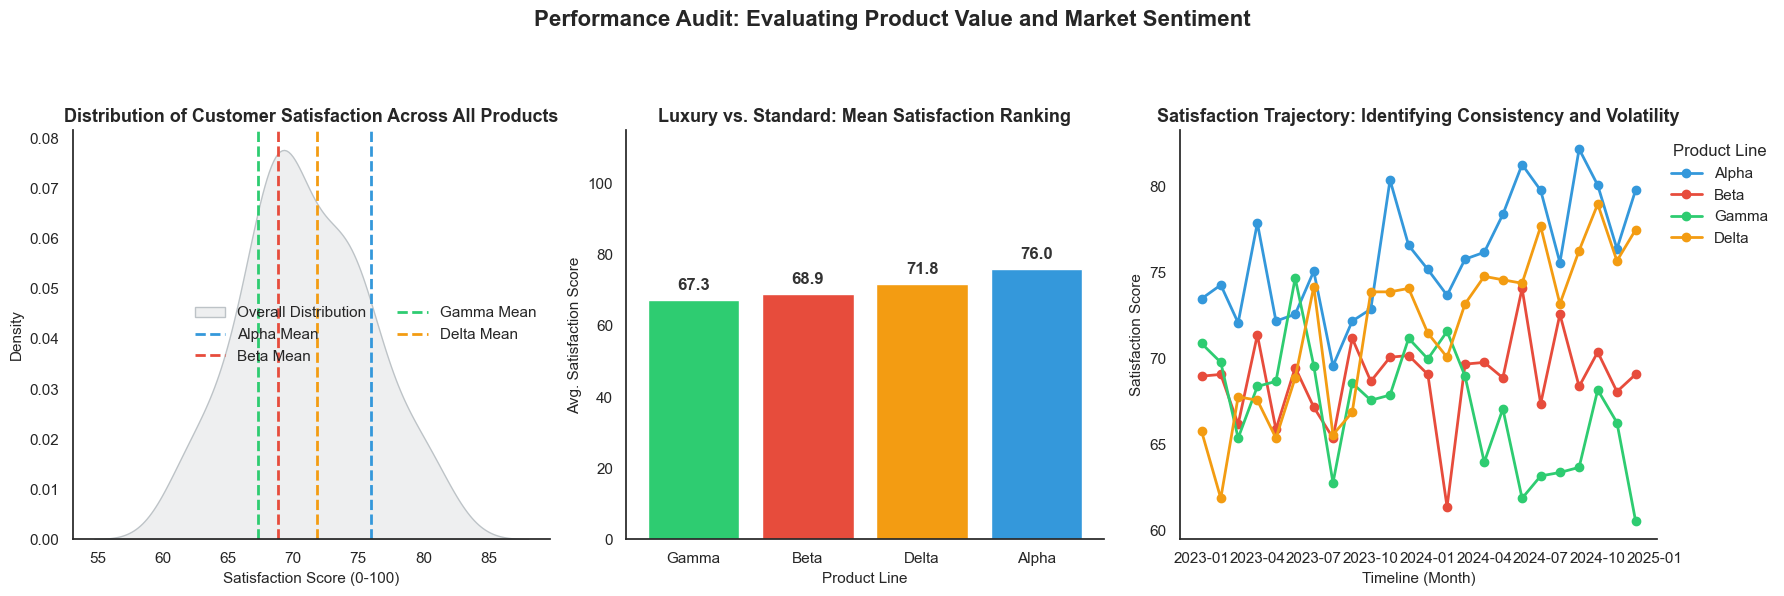

In [11]:
# TODO: Build the three-panel figure
#
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))
#
# Panel 1 — Distribution
#   Suggested: overlapping histograms, KDE plots, or violin plots
#   Show where each product line sits within the overall satisfaction distribution
#
# Panel 2 — Comparison
#   Suggested: grouped bar chart with error bars, box plot, or strip plot
#   Show group means and their overlap/spread
#
# Panel 3 — Trend
#   Suggested: line plot with confidence bands
#   Show how monthly_revenue changes over time per product line
#
# fig.suptitle("...", fontsize=16, fontweight="bold", y=1.02)
# plt.tight_layout()
# plt.show()

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Set global style for a clean, professional look
sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'

# Define a consistent color palette for Product Lines
product_colors = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

# Create the 3-panel figure
fig = plt.subplots(1,3,figsize=(18,6))
(ax1, ax2, ax3) = fig[1]

#1. DISTRIBUTION PANEL
# Showing where specific products sit within the overall satisfaction density
sns.kdeplot(data=df, x="satisfaction_score", fill=True, color="#bdc3c7", ax=ax1, label="Overall Distribution")
for product, color in product_colors.items():
    product_mean = df[df["product"] == product]["satisfaction_score"].mean()
    ax1.axvline(product_mean, color=color, linestyle="--", linewidth=2, label=f"{product} Mean")

ax1.set_title("Distribution of Customer Satisfaction Across All Products", fontsize=13, fontweight="bold")
ax1.set_xlabel("Satisfaction Score (0-100)", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)
ax1.legend(frameon=False, ncol=2)

#2. COMPARISON PANEL
# Using the logic from your Chart 1 redesign
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()
comparison_colors = [product_colors[name] for name in avg_sat.index]

bars = ax2.bar(avg_sat.index, avg_sat.values, color=comparison_colors)
ax2.set_ylim(0, 115) # Extra room for labels
ax2.set_title("Luxury vs. Standard: Mean Satisfaction Ranking", fontsize=13, fontweight="bold")
ax2.set_ylabel("Avg. Satisfaction Score", fontsize=11)
ax2.set_xlabel("Product Line", fontsize=11)

# Adding data labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 2, f'{height:.1f}', 
             ha='center', va='bottom', fontweight='bold', color='#333333')

#3. TREND PANEL
# Combining the trend logic for a comparative look over time
for product, color in product_colors.items():
    data = df[df["product"] == product]
    ax3.plot(data["month"], data["satisfaction_score"], marker='o', color=color, label=product, linewidth=2)

ax3.set_title("Satisfaction Trajectory: Identifying Consistency and Volatility", fontsize=13, fontweight="bold")
ax3.set_xlabel("Timeline (Month)", fontsize=11)
ax3.set_ylabel("Satisfaction Score", fontsize=11)
ax3.legend(title="Product Line", frameon=False, loc='upper left', bbox_to_anchor=(1, 1))

plt.suptitle("Performance Audit: Evaluating Product Value and Market Sentiment", 
             fontsize=16, fontweight="bold", y=1.02)

sns.despine()
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.show()

---

## Bonus: Peer Review Checklist

If working with a partner, swap notebooks and evaluate their visualizations using this checklist:

| Criterion | Yes / No | Notes |
|---|---|---|
| Y-axis starts at zero (or a break is clearly marked) | | |
| Title describes the finding, not just the variables | | |
| Axes are labeled with units | | |
| Color is used to encode meaning, not decoration | | |
| Uncertainty is shown where relevant (error bars, bands) | | |
| The chart can be understood without a verbal walkthrough | | |
| No chart junk (unnecessary gridlines, 3D effects, etc.) | | |